READ THROUGH ENTIRE CODE, MAKE SURE EVERYTHING CHECKS OUT
- Do markdown test explainations make sense?
- Markdown text aligns with what's actually in the code?

# CNN-LSTM — IMU Gym Exercise Recognition

*   List item
*   List item



**Adapted for:**
- IMU-only input (6 channels: accel + gyro) at **20 Hz**
- **2 classes**: exercise (1,3) vs exercise (5,5)
- **LOSO** (Leave-One-Subject-Out) cross-validation by participant

---
## 0. Setup & Configuration

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data --
DATA_PATH = "data/golden_dataset_v10.csv"


# -- Classes to keep: (parent, child) pairs --
# (1,3) = exercise 0, (5,5) = exercise 1
KEEP_PAIRS = [(1, 3), (5, 5)]

# Maps parent value -> model label (must be 0-indexed for CrossEntropyLoss)
LABEL_MAP = {1: 0, 5: 1}
NUM_CLASSES = len(LABEL_MAP)  # 2

# -- Preprocessing --
SAMPLING_RATE    = 20       # Hz
NUM_IMU_CHANNELS = 6        # accel_xyz + gyro_xyz
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap

# -- Training --
EPOCHS        = 75
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
PATIENCE      = 15

# -- Test set from golden_dataset (held out from LOSO and hyperparameter sweep) --
# Used in cell 14 to split the golden dataset. Run the load + filter cells
# first to see which participants exist in golden_dataset_v10, then
# pick 1-2 to hold out here.
TEST_PARTICIPANTS = [18]   # <-- adjust based on golden dataset participants

# -- Variant eval participant from OurData (held out from fine-tuning) --
# Used in cell 47 to split OurData variants into fine-tune vs eval.
# OurData contains participants [15, 16, 17, 18, 19].
VARIANT_EVAL_PARTICIPANTS = [15]

# -- IMU column names (must match your CSV) --
IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]

---
## 1. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# SET YOUR BASE PATH HERE
# This is the folder that contains our "data" subfolder.
# ============================================================
import os

BASE_PATH = "/content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
FULL_DATA_PATH = os.path.join(BASE_PATH, DATA_PATH)

print(f"Loading: {FULL_DATA_PATH}")
df_full = pd.read_csv(FULL_DATA_PATH)
print(f"Full dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Columns: {list(df_full.columns)}")
df_full.head()

Loading: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/golden_dataset_v10.csv
Full dataset: 24,788 rows, 12 columns
Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID', 'dataset']


,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID,dataset
0,-0.607620,0.260122,-0.244656,-3.580708,61.459589,-11.303101,5,5,18,1,38,ourdata
1,0.938619,-0.286055,-0.031800,-18.836250,-37.515571,16.490179,5,5,18,1,38,ourdata
2,-0.383179,0.059054,-0.093280,-33.899180,-2.453326,0.954961,5,5,18,1,38,ourdata
3,0.154184,0.109962,0.244019,-1.578370,8.389933,3.827915,5,5,18,1,38,ourdata
4,-0.075512,-0.099518,-0.049661,-3.277634,17.204920,8.430352,5,5,18,1,38,ourdata


---
## 2. Filter Data — Keep Only Target Exercises

We keep only:
- `(parent=1, child=3)` — exercise class 0
- `(parent=5, child=5)` — exercise class 1

All other data is discarded. We find IDs that contain
at least one row of `(1,3)` or `(5,5)`, then within those IDs keep only
matching rows.

In [ ]:
# Find rows matching target (parent, child) pairs
pair_mask = pd.Series(False, index=df_full.index)
for p, c in KEEP_PAIRS:
    pair_mask |= (df_full["parent"] == p) & (df_full["child"] == c)

df_filtered = df_full[pair_mask].copy().reset_index(drop=True)

# Create model label from parent column
df_filtered["label"] = df_filtered["parent"].map(LABEL_MAP)

print(f"Filtered dataset: {len(df_filtered):,} rows")
print(f"\nClass distribution:")
for (p, c), pair_label in zip(KEEP_PAIRS, LABEL_MAP.values()):
    count = (df_filtered["label"] == pair_label).sum()
    print(f"  parent={p}, child={c}  →  label {pair_label}  →  {count:,} rows")

print(f"\nParticipants: {sorted(df_filtered['participant'].unique())}")
print(f"Unique IDs:   {df_filtered['ID'].nunique()}")

Filtered dataset: 24,788 rows

Class distribution:
  parent=1, child=3  →  label 0  →  15,203 rows
  parent=5, child=5  →  label 1  →  9,585 rows

Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Unique IDs:   43


In [ ]:
# Quick sanity check: show a sample ID's label sequence
sample_id = df_filtered["ID"].unique()[0]
sample = df_filtered[df_filtered["ID"] == sample_id]
print(f"ID {sample_id}: {len(sample)} rows")
print(f"  Label sequence: {sample['label'].unique()} "
      f"(0=exercise(1,3), 1=exercise(5,5))")
print(f"  Participant: {sample['participant'].iloc[0]}")
print(f"  Parent values: {sample['parent'].unique()}")
print(f"  Child values:  {sample['child'].unique()}")

ID 38: 480 rows
  Label sequence: [1] (0=exercise(1,3), 1=exercise(5,5))
  Participant: 18
  Parent values: [5]
  Child values:  [5]


---
## 3. Preprocessing

**Denoising at 20 Hz:** The paper used a bandpass filter of 1–20 Hz at 50 Hz sampling. At 20 Hz, the Nyquist frequency is only 10 Hz, so a 1–20 Hz band is impossible. Instead we use a **1–9 Hz bandpass**, which:
- Removes DC drift and slow offset changes below 1 Hz
- Keeps the core human motion band (~1–8 Hz for exercise movements)
- Stays safely below the 10 Hz Nyquist limit

**Unit conversion:** Acceleration is converted from G's to m/s² (×9.81) before denoising.

**Segmentation** is done **per ID** to avoid windows that span across different recordings.

In [ ]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data at 20 Hz.

    Steps:
      1. Denoise   — 6th-order zero-phase Butterworth bandpass (1–9 Hz)
      2. Normalize  — Per-channel min–max scaling to [0, 1]
      3. Segment    — Sliding window per ID with majority-vote labels
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=1.0, highcut=9.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)  # 40 samples
        self.step_size = int(self.window_size * (1.0 - overlap)) # 20 samples
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {0.5 * self.fs} Hz")
        print(f"  Bandpass:       {self.lowcut}–{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        """
        6th-order zero-phase Butterworth bandpass (1–9 Hz), per channel.
        At 20 Hz sampling, Nyquist = 10 Hz, so 9 Hz is the safe upper bound.
        """
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            print("  Warning: filter band invalid, skipping denoise")
            return data.copy()
        b, a = butter(self.filter_order, [lo, hi], btype="band")
        out = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]  # too short to filter
        return out

    def fit_normalize(self, data):
        """Fit per-channel min/max from training data, return normalized."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data):
        """Apply previously fitted min–max (for validation data)."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data):
        denom = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    def segment_single(self, data, labels):
        """Sliding window on a single continuous sequence."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant"):
        """
        Segment per ID to avoid windows spanning different recordings.

        Returns:
            X:            (N, window_size, channels)
            y:            (N,) integer labels
            participants: (N,) participant ID per window (for LOSO)
        """
        all_X, all_y, all_participants = [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]

            if len(imu) < self.window_size:
                continue  # skip IDs shorter than one window

            windows, window_labels = self.segment_single(imu, labels)
            all_X.extend(windows)
            all_y.extend(window_labels)
            all_participants.extend([participant] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_participants))

In [ ]:
# Run preprocessing
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=1.0,
    highcut=9.0,
)

# Step 0: Convert acceleration from G's to m/s²
print("\nConverting acceleration from G's to m/s²...")
accel_cols = ["x_accel", "y_accel", "z_accel"]
df_filtered[accel_cols] = df_filtered[accel_cols] * 9.81
print(f"  Accel range after conversion: "
      f"[{df_filtered[accel_cols].min().min():.2f}, "
      f"{df_filtered[accel_cols].max().max():.2f}] m/s²")

# Step 1: Denoise the raw IMU columns (operates on the full filtered dataframe)
print("\nDenoising...")
imu_raw = df_filtered[IMU_COLS].values
imu_denoised = pp.denoise(imu_raw)

# Put denoised values back into the dataframe
df_processed = df_filtered.copy()
df_processed[IMU_COLS] = imu_denoised

# Step 2: Normalize
print("Normalizing...")
imu_normalized = pp.fit_normalize(df_processed[IMU_COLS].values)
df_processed[IMU_COLS] = imu_normalized

print(f"  Value range: [{df_processed[IMU_COLS].min().min():.4f}, "
      f"{df_processed[IMU_COLS].max().max():.4f}]")

# Step 3: Segment per ID
print("\nSegmenting per ID...")
X, y, participants = pp.segment_by_id(df_processed, IMU_COLS)

print(f"\nResult:")
print(f"  X: {X.shape}  (windows × timesteps × channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes)")
print(f"  Participants: {np.unique(participants)}")
print(f"\nWindows per class:")
for label_val, label_name in zip([0, 1], ["exercise (1,3)", "exercise (5,5)"]):
    print(f"  Label {label_val} ({label_name}): {(y == label_val).sum()}")

Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       1.0–9.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Converting acceleration from G's to m/s²...
  Accel range after conversion: [-10.11, 12.61] m/s²

Denoising...
Normalizing...
  Value range: [0.0000, 1.0000]

Segmenting per ID...

Result:
  X: (1176, 40, 6)  (windows × timesteps × channels)
  y: (1176,)  (2 classes)
  Participants: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Windows per class:
  Label 0 (exercise (1,3)): 725
  Label 1 (exercise (5,5)): 451


---
## 4. Dev / Test Split

Hold out one or more participants as a **final test set** that is never touched during LOSO development. LOSO runs only on the remaining "dev" participants.

- **Dev set** → used for LOSO cross-validation (model selection, hyperparameter tuning)
- **Test set** → evaluated once at the very end for an unbiased performance estimate

In [ ]:
# Split into dev and test based on participant
test_mask = np.isin(participants, TEST_PARTICIPANTS)
dev_mask  = ~test_mask

X_dev,  y_dev,  participants_dev  = X[dev_mask],  y[dev_mask],  participants[dev_mask]
X_test, y_test, participants_test = X[test_mask], y[test_mask], participants[test_mask]

print(f"Test participants: {TEST_PARTICIPANTS}")
print(f"Dev  participants: {sorted(np.unique(participants_dev))}")
print(f"\nDev  set: {X_dev.shape[0]:,} windows")
print(f"Test set: {X_test.shape[0]:,} windows")

print(f"\nDev class distribution:")
for lv, ln in zip([0, 1], ["exercise (1,3)", "exercise (5,5)"]):
    print(f"  Label {lv} ({ln}): {(y_dev == lv).sum()}")

print(f"\nTest class distribution:")
for lv, ln in zip([0, 1], ["exercise (1,3)", "exercise (5,5)"]):
    print(f"  Label {lv} ({ln}): {(y_test == lv).sum()}")

Test participants: [18]
Dev  participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]

Dev  set: 1,091 windows
Test set: 85 windows

Dev class distribution:
  Label 0 (exercise (1,3)): 681
  Label 1 (exercise (5,5)): 410

Test class distribution:
  Label 0 (exercise (1,3)): 44
  Label 1 (exercise (5,5)): 41


---
## 5. Model — CNN-LSTM (Section 3.4)

In [ ]:
class ResBiGRUBlock(nn.Module):
    """
    Residual Bidirectional GRU block (Section 3.4.2, Figure 6, Eqs. 4-6).

    Each stacked layer:
        h = BiGRU(x)           # forward + backward GRU, concatenated
        r = Linear(x)          # project input to match h's dimension
        x = LayerNorm(r + h)   # residual connection + normalization
    """

    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)
            r = blk["proj"](x)
            x = blk["ln"](r + h)
        return x

In [ ]:
class CNNResBiGRU(nn.Module):
    """
    CNN-ResBiGRU model (Section 3.4, Figure 5).

    Input:  (batch, seq_len, in_channels)
    Output: (batch, num_classes) — raw logits
    """

    def __init__(self, in_channels=6, num_classes=2,
                 conv_filters=(64, 128, 256, 512), kernel=3, pool=2,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128):
        super().__init__()

        # 4 × Conv Blocks (Section 3.4.1)
        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.MaxPool1d(pool),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        # Residual BiGRU (Section 3.4.2)
        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)         # (B, T, C) → (B, C, T) for Conv1d
        x = self.conv(x)
        x = x.permute(0, 2, 1)         # back to (B, T', C') for GRU
        x = self.resbigru(x)
        x = x.mean(dim=1)              # global average pooling
        return self.head(x)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)

        # CNN
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (batch, channels, seq_len//4)
        x = F.relu(self.bn3(self.conv3(x)))

        # Prepare for LSTM
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq_len_reduced, hidden_dim)
        out = lstm_out[:, -1, :]    # last hidden state

        # Classifier
        out = self.fc(out)
        return out

In [ ]:
# Quick architecture check
test_model = CNN_LSTM(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
test_output = test_model(test_input)

n_params = sum(p.numel() for p in test_model.parameters())
print(f"Input shape:  {tuple(test_input.shape)}")
print(f"Output shape: {tuple(test_output.shape)}")
print(f"Parameters:   {n_params:,}")

del test_model, test_input, test_output

Input shape:  (2, 40, 6)
Output shape: (2, 2)
Parameters:   142,786


---
## 6. Hyperparameter Search via LOSO

**Random search** over hyperparameter configurations. Each candidate runs a full
Leave-One-Subject-Out sweep on the dev participants. The configuration with the
best mean F1 is selected for the final model.

### How LOSO Cross-Validation Works (and Why We're Using It This Way)

We want a reliable estimate of how well our model will perform on people it has never seen before. The simplest way to measure this would be to split our participants into a training group and a validation group — but that gives us exactly one number, and that number depends heavily on which participants happened to end up in which group. One unlucky split could make a good model look bad, or vice versa.

**Leave-One-Subject-Out (LOSO)** solves this by running every possible one-participant holdout. If we have 4 dev participants, we train 4 separate models: the first holds out participant A and trains on B, C, D. The second holds out B and trains on A, C, D. And so on. Each model is trained completely from scratch — there's no weight carryover between folds. For each fold, the held-out participant acts as the validation set, giving us an accuracy score. At the end, we have 4 scores, one per participant. Averaging them gives us a much more robust estimate than any single train/val split could.

**Why run LOSO once per hyperparameter configuration?** Our hyperparameter search is trying to find the combination of learning rate, batch size, epochs, and patience that produces the best-generalizing model. Since LOSO is our measurement tool for "how well does this generalize," we need to apply it consistently to every configuration we're comparing. A single configuration runs one full LOSO sweep across all folds and produces one aggregate F1 score. We then compare aggregate scores across configurations to pick the winner. Critically, we do **not** change hyperparameters between folds within a single sweep — if we did, the aggregate score wouldn't represent any coherent configuration and we'd be subtly overfitting our tuning to specific participants.

**Why random search instead of trying every combination?** A full grid search over our parameter grid would mean running LOSO for every possible combination, which adds up quickly in compute time. Random search samples a subset of combinations and usually finds a nearly-optimal configuration in a fraction of the time, because in practice only one or two hyperparameters tend to meaningfully affect results — and random sampling covers those well.

**Test participants are held out from all of this.** The participant(s) in `TEST_PARTICIPANTS` do not appear in any LOSO fold — not for training, not for validation. They exist purely for the final evaluation at the very end, once we've picked our winning hyperparameters and trained the final model on all dev participants. This guarantees that our reported test accuracy reflects performance on data the model has truly never seen during development.

In [ ]:
def train_one_fold(model, X_tr, y_tr, X_va, y_va, device,
                   epochs=100, batch_size=64, lr=1e-3, patience=15,
                   verbose=True):
    """
    Train a single LOSO fold with early stopping.

    Returns:
        model:   Best model (weights restored)
        history: Dict of training curves
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = loss_fn(val_logits, y_va_t).item()
            val_acc = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"    Early stopping at epoch {epoch+1}")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

In [ ]:
def run_loso(X, y, participants, num_classes, device,
             epochs=100, batch_size=64, lr=1e-3, patience=15):
    """
    Leave-One-Subject-Out cross-validation.

    Trains on all participants except one, validates on the held-out participant,
    then rotates through every participant.
    """
    logo = LeaveOneGroupOut()
    unique_participants = np.unique(participants)
    n_folds = len(unique_participants)

    print(f"LOSO: {n_folds} folds (one per participant)")
    print(f"Participants: {sorted(unique_participants)}")

    results = {
        "participant": [], "acc": [], "prec": [], "rec": [],
        "f1": [], "loss": [], "histories": [],
        "n_train": [], "n_val": [],
        "all_y_true": [], "all_y_pred": [],  # for aggregated confusion matrix
    }

    for fold, (tr_idx, va_idx) in enumerate(logo.split(X, y, participants)):
        held_out = participants[va_idx[0]]
        print(f"\n{'═'*55}")
        print(f"  Fold {fold+1}/{n_folds} — Hold out participant {held_out}")
        print(f"  Train: {len(tr_idx)} windows  |  Val: {len(va_idx)} windows")
        print(f"{'═'*55}")

        # Build fresh model
        model = CNN_LSTM(
            in_channels=X.shape[2],
            num_classes=num_classes,
        ).to(device)

        if fold == 0:
            n_params = sum(p.numel() for p in model.parameters())
            print(f"  Parameters: {n_params:,}")

        # Train
        model, history = train_one_fold(
            model, X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
            device=device, epochs=epochs, batch_size=batch_size,
            lr=lr, patience=patience,
        )

        # Evaluate
        model.eval()
        with torch.no_grad():
            X_va_t = torch.FloatTensor(X[va_idx]).to(device)
            y_pred = model(X_va_t).argmax(1).cpu().numpy()
        y_true = y[va_idx]

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

        results["participant"].append(held_out)
        results["acc"].append(acc)
        results["prec"].append(prec)
        results["rec"].append(rec)
        results["f1"].append(f1)
        results["loss"].append(min(history["val_loss"]))
        results["histories"].append(history)
        results["n_train"].append(len(tr_idx))
        results["n_val"].append(len(va_idx))
        results["all_y_true"].extend(y_true)
        results["all_y_pred"].extend(y_pred)

        print(f"\n  Participant {held_out} =>  "
              f"Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%")

    return results

In [ ]:
# ============================================================
# Random Hyperparameter Search over full LOSO
# ============================================================
import random

# Define search space
param_grid = {
    "lr":         [1e-3, 5e-4, 1e-4],
    "batch_size":  [32, 64],
    "epochs":      [50, 75, 100],
    "patience":    [10, 15, 20],
}

# Sample N random configurations (set to however many you can afford)
N_SAMPLES = 10
random.seed(42)

all_combos = [
    dict(zip(param_grid.keys(), vals))
    for vals in __import__("itertools").product(*param_grid.values())
]
sampled_configs = random.sample(all_combos, min(N_SAMPLES, len(all_combos)))

print(f"Search space: {len(all_combos)} total combinations")
print(f"Sampling {len(sampled_configs)} random configurations\n")

sweep_results = []

for i, config in enumerate(sampled_configs):
    print(f"\n{'='*60}")
    print(f"  Config {i+1}/{len(sampled_configs)}: {config}")
    print(f"{'='*60}")

    loso_out = run_loso(
        X_dev, y_dev, participants_dev,
        num_classes=NUM_CLASSES,
        device=DEVICE,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        lr=config["lr"],
        patience=config["patience"],
    )

    mean_f1  = np.mean(loso_out["f1"])
    std_f1   = np.std(loso_out["f1"])
    mean_acc = np.mean(loso_out["acc"])

    sweep_results.append({
        **config,
        "mean_f1": mean_f1,
        "std_f1": std_f1,
        "mean_acc": mean_acc,
        "loso_output": loso_out,  # keep full results for the winner
    })

    print(f"  → Mean F1: {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)  "
          f"Mean Acc: {mean_acc*100:.2f}%")

# ---- Pick the best config ----
sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k != "loso_output"}
                          for r in sweep_results])
sweep_df = sweep_df.sort_values("mean_f1", ascending=False).reset_index(drop=True)

print(f"\n\n{'='*60}")
print("  SWEEP RESULTS (sorted by Mean F1)")
print(f"{'='*60}")
display(sweep_df.round(4))

# Store best config and its LOSO output for downstream cells
best_idx = sweep_df.index[0]
best_config = sampled_configs[sweep_results.index(
    [r for r in sweep_results
     if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]
)]
results = [r for r in sweep_results
           if r["mean_f1"] == sweep_df.iloc[0]["mean_f1"]][0]["loso_output"]

best_lr         = best_config["lr"]
best_batch_size = best_config["batch_size"]
best_epochs     = best_config["epochs"]
best_patience   = best_config["patience"]

print(f"\n✓ Best configuration:")
print(f"  lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")
print(f"  Mean F1: {np.mean(results['f1'])*100:.2f}% "
      f"(±{np.std(results['f1'])*100:.2f}%)")

In [ ]:
# ============================================================
# Train with Best Known Hyperparameters (found via prior sweep)
# ============================================================

best_lr         = 0.001
best_batch_size = 32
best_epochs     = 100
best_patience   = 10

print(f"Using best configuration from prior hyperparameter sweep:")
print(f"  lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")

results = run_loso(
    X_dev, y_dev, participants_dev,
    num_classes=NUM_CLASSES,
    device=DEVICE,
    epochs=best_epochs,
    batch_size=best_batch_size,
    lr=best_lr,
    patience=best_patience,
)

mean_f1  = np.mean(results["f1"])
std_f1   = np.std(results["f1"])
mean_acc = np.mean(results["acc"])

print(f"\n✓ LOSO Results:")
print(f"  Mean F1:  {mean_f1*100:.2f}% (±{std_f1*100:.2f}%)")
print(f"  Mean Acc: {mean_acc*100:.2f}%")

Using best configuration from prior hyperparameter sweep:
  lr=0.001, batch_size=32, epochs=100, patience=10
LOSO: 18 folds (one per participant)
Participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]

═══════════════════════════════════════════════════════
  Fold 1/18 — Hold out participant 1
  Train: 1059 windows  |  Val: 32 windows
═══════════════════════════════════════════════════════
  Parameters: 142,786
    Epoch  10  train_loss=0.0097  val_loss=3.1980  val_acc=0.3125  lr=1.0e-03
    Early stopping at epoch 18

  Participant 1 =>  Acc: 100.00%  F1: 100.00%

═══════════════════════════════════════════════════════
  Fold 2/18 — Hold out participant 2
  Train: 1055 windows  |  Val: 36 windows
═══════════════════════════════════════════════════════
    Epoch  10  train_loss=0.0013  

---
## 7. LOSO Results Summary

In [ ]:
# Per-participant results table
results_df = pd.DataFrame({
    "Participant":  results["participant"],
    "Train Windows": results["n_train"],
    "Val Windows":   results["n_val"],
    "Accuracy (%)":  [a * 100 for a in results["acc"]],
    "Precision (%)":  [p * 100 for p in results["prec"]],
    "Recall (%)":    [r * 100 for r in results["rec"]],
    "F1-score (%)":  [f * 100 for f in results["f1"]],
    "Best Val Loss": results["loss"],
})

print("Per-Participant Results (LOSO)")
print("=" * 70)
display(results_df.round(2))

print(f"\nOverall Averages:")
print(f"  Accuracy:  {np.mean(results['acc'])*100:.2f}% "
      f"(+/- {np.std(results['acc'])*100:.2f}%)")
print(f"  Precision: {np.mean(results['prec'])*100:.2f}% "
      f"(+/- {np.std(results['prec'])*100:.2f}%)")
print(f"  Recall:    {np.mean(results['rec'])*100:.2f}% "
      f"(+/- {np.std(results['rec'])*100:.2f}%)")
print(f"  F1-score:  {np.mean(results['f1'])*100:.2f}% "
      f"(+/- {np.std(results['f1'])*100:.2f}%)")

Per-Participant Results (LOSO)


,Participant,Train Windows,Val Windows,Accuracy (%),Precision (%),Recall (%),F1-score (%),Best Val Loss
0,1,1059,32,100.00,100.00,100.00,100.00,0.00
1,2,1055,36,100.00,100.00,100.00,100.00,0.00
2,3,1072,19,100.00,100.00,100.00,100.00,0.00
3,4,1080,11,100.00,100.00,100.00,100.00,0.00
4,5,1061,30,100.00,100.00,100.00,100.00,0.00
5,6,1070,21,100.00,100.00,100.00,100.00,0.00
6,7,1071,20,100.00,100.00,100.00,100.00,0.00
7,8,1071,20,100.00,100.00,100.00,100.00,0.00
8,9,1058,33,100.00,100.00,100.00,100.00,0.01
9,10,1066,25,100.00,100.00,100.00,100.00,0.00



Overall Averages:
  Accuracy:  99.21% (+/- 3.27%)
  Precision: 99.24% (+/- 3.12%)
  Recall:    99.14% (+/- 3.54%)
  F1-score:  99.17% (+/- 3.41%)


---
## 8. Visualize Training Curves

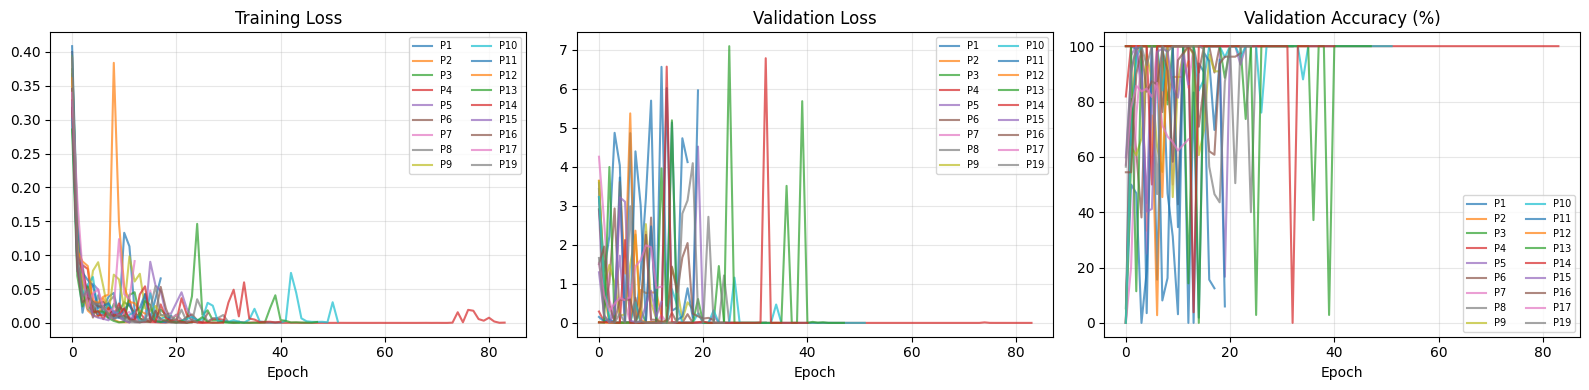

In [ ]:
n_folds = len(results["histories"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, hist in enumerate(results["histories"]):
    p = results["participant"][i]
    axes[0].plot(hist["train_loss"], alpha=0.7, label=f"P{p}")
    axes[1].plot(hist["val_loss"], alpha=0.7, label=f"P{p}")
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.7, label=f"P{p}")

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

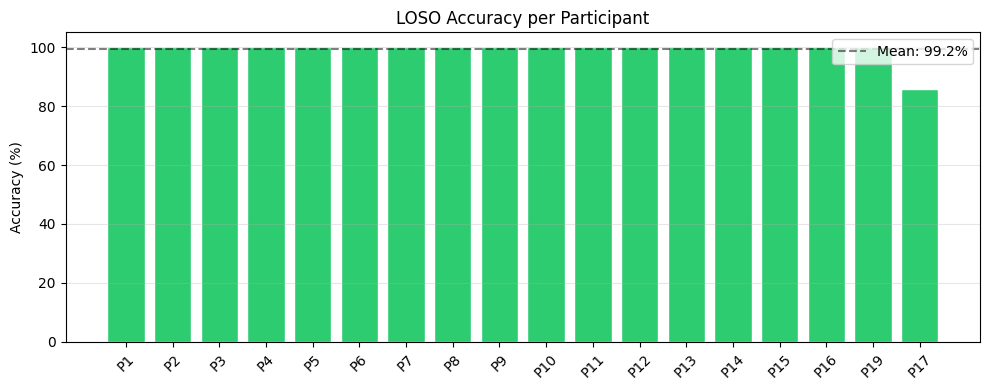

In [ ]:
# Per-participant accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 4))

participants_sorted = sorted(zip(results["participant"], results["acc"]),
                             key=lambda x: x[1], reverse=True)
ps, accs = zip(*participants_sorted)
colors = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.6 else "#e74c3c"
          for a in accs]

ax.bar(range(len(ps)), [a * 100 for a in accs], color=colors, edgecolor="white")
ax.set_xticks(range(len(ps)))
ax.set_xticklabels([f"P{p}" for p in ps], rotation=45)
ax.set_ylabel("Accuracy (%)")
ax.set_title("LOSO Accuracy per Participant")
ax.axhline(y=np.mean(results["acc"]) * 100, color="black",
           linestyle="--", alpha=0.5, label=f"Mean: {np.mean(results['acc'])*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 9. LOSO Confusion Matrix (Aggregated)

In [ ]:
# Use predictions already collected during LOSO (no retraining needed)
all_y_true = np.array(results["all_y_true"])
all_y_pred = np.array(results["all_y_pred"])

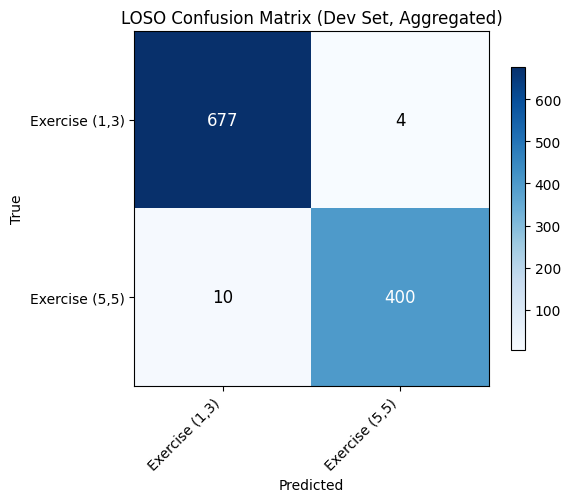


Classification Report:
                precision    recall  f1-score   support

Exercise (1,3)     0.9854    0.9941    0.9898       681
Exercise (5,5)     0.9901    0.9756    0.9828       410

      accuracy                         0.9872      1091
     macro avg     0.9878    0.9849    0.9863      1091
  weighted avg     0.9872    0.9872    0.9871      1091



In [ ]:
# Plot confusion matrix
class_names = ["Exercise (1,3)", "Exercise (5,5)"]
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=12)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("LOSO Confusion Matrix (Dev Set, Aggregated)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred,
                            target_names=class_names, digits=4))

---
## 10. Final Test Evaluation

Train on **all dev participants** using the **best hyperparameters from the sweep**,
evaluate on the **held-out test participants** once.

In [ ]:
print(f"Training on all dev data ({X_dev.shape[0]} windows)...")
print(f"Testing on held-out participants {TEST_PARTICIPANTS} ({X_test.shape[0]} windows)...")
print(f"Using best config: lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")

# Build and train model on all dev data with best hyperparameters
test_model = CNN_LSTM(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
).to(DEVICE)

optimizer = torch.optim.Adam(test_model.parameters(), lr=best_lr)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

X_dev_t = torch.FloatTensor(X_dev).to(DEVICE)
y_dev_t = torch.LongTensor(y_dev).to(DEVICE)
train_dl = DataLoader(TensorDataset(X_dev_t, y_dev_t),
                      batch_size=best_batch_size, shuffle=True)

test_model.train()
for epoch in range(best_epochs):
    total_loss, n = 0.0, 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(test_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1
    avg_loss = total_loss / n
    scheduler.step(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}  loss={avg_loss:.4f}  "
              f"lr={optimizer.param_groups[0]['lr']:.1e}")

# Final predictions on test set
test_model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    test_preds = test_model(X_test_t).argmax(1).cpu().numpy()

test_acc  = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec  = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1   = f1_score(y_test, test_preds, average="macro", zero_division=0)

print(f"\n{'='*55}")
print(f"  FINAL TEST RESULTS (participants {TEST_PARTICIPANTS})")
print(f"{'='*55}")
print(f"  Accuracy:  {test_acc*100:.2f}%")
print(f"  Precision: {test_prec*100:.2f}%")
print(f"  Recall:    {test_rec*100:.2f}%")
print(f"  F1-score:  {test_f1*100:.2f}%")

Training on all dev data (1091 windows)...
Testing on held-out participants [18] (85 windows)...
Using best config: lr=0.001, batch_size=32, epochs=100, patience=10
  Epoch  10  loss=0.0438  lr=1.0e-03
  Epoch  20  loss=0.0309  lr=5.0e-04
  Epoch  30  loss=0.0020  lr=2.5e-04
  Epoch  40  loss=0.0024  lr=6.3e-05
  Epoch  50  loss=0.0017  lr=3.1e-05
  Epoch  60  loss=0.0029  lr=3.1e-05
  Epoch  70  loss=0.0025  lr=3.1e-05
  Epoch  80  loss=0.0011  lr=1.6e-05
  Epoch  90  loss=0.0067  lr=7.8e-06
  Epoch 100  loss=0.0013  lr=3.9e-06

  FINAL TEST RESULTS (participants [18])
  Accuracy:  100.00%
  Precision: 100.00%
  Recall:    100.00%
  F1-score:  100.00%


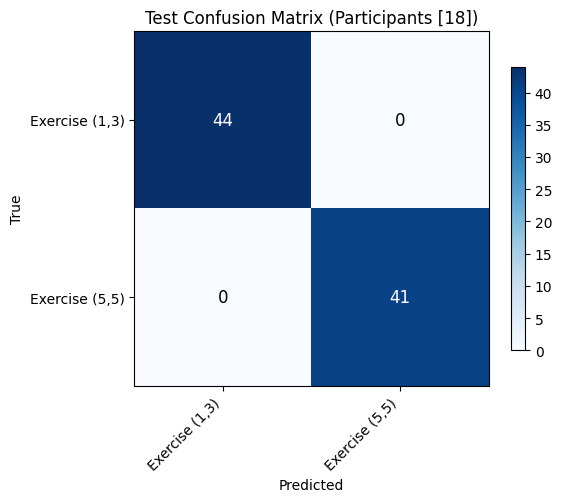


Test Classification Report:
                precision    recall  f1-score   support

Exercise (1,3)     1.0000    1.0000    1.0000        44
Exercise (5,5)     1.0000    1.0000    1.0000        41

      accuracy                         1.0000        85
     macro avg     1.0000    1.0000    1.0000        85
  weighted avg     1.0000    1.0000    1.0000        85



In [ ]:
# Test set confusion matrix
class_names = ["Exercise (1,3)", "Exercise (5,5)"]
cm_test = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_test, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_test[i, j]}", ha="center", va="center",
                color="white" if cm_test[i, j] > cm_test.max() / 2 else "black",
                fontsize=12)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Test Confusion Matrix (Participants {TEST_PARTICIPANTS})", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTest Classification Report:")
print(classification_report(y_test, test_preds,
                            target_names=class_names, digits=4))

---
## 11. Save / Load Model

In [ ]:
# Save the test-evaluated model (trained on all dev data)
save_path = os.path.join(BASE_PATH, "cnn_lstm_imu.pt")
torch.save(test_model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/cnn_lstm_imu.pt


In [ ]:
# Load for inference
loaded_model = CNN_LSTM(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
).to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path, map_location=DEVICE))
loaded_model.eval()

# Predict on a single window
sample = torch.FloatTensor(X_test[:1]).to(DEVICE)
with torch.no_grad():
    logits = loaded_model(sample)
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()

label_names = {0: "Exercise (1,3)", 1: "Exercise (5,5)"}
print(f"Predicted: {label_names[pred]}")
print(f"Probabilities: {dict(zip(label_names.values(), probs[0].cpu().numpy().round(4)))}")

Predicted: Exercise (5,5)
Probabilities: {'Exercise (1,3)': np.float32(0.0065), 'Exercise (5,5)': np.float32(0.9935)}


---
## 12. Visual Inspection: Ground Truth vs Predictions (LOSO)

In [ ]:
# ============================================================
# Visual Inspection: Ground Truth vs Predictions (LOSO)
# ============================================================

# Rebuild per-fold predictions with fold boundaries
logo = LeaveOneGroupOut()
fold_data = []

for fold, (tr_idx, va_idx) in enumerate(logo.split(X_dev, y_dev, participants_dev)):
    held_out = participants_dev[va_idx[0]]

    model = CNN_LSTM(in_channels=X_dev.shape[2], num_classes=NUM_CLASSES).to(DEVICE)
    model, _ = train_one_fold(
        model, X_dev[tr_idx], y_dev[tr_idx], X_dev[va_idx], y_dev[va_idx],
        device=DEVICE, epochs=EPOCHS, batch_size=BATCH_SIZE,
        lr=LEARNING_RATE, patience=PATIENCE, verbose=False,
    )
    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_dev[va_idx]).to(DEVICE)).argmax(1).cpu().numpy()

    fold_data.append({
        "participant": held_out,
        "y_true": y_dev[va_idx],
        "y_pred": preds,
    })
    print(f"  Fold {fold+1} done (participant {held_out})")

  Fold 1 done (participant 1)
  Fold 2 done (participant 2)
  Fold 3 done (participant 3)
  Fold 4 done (participant 4)
  Fold 5 done (participant 5)
  Fold 6 done (participant 6)
  Fold 7 done (participant 7)
  Fold 8 done (participant 8)
  Fold 9 done (participant 9)
  Fold 10 done (participant 10)
  Fold 11 done (participant 11)
  Fold 12 done (participant 12)
  Fold 13 done (participant 13)
  Fold 14 done (participant 14)
  Fold 15 done (participant 15)
  Fold 16 done (participant 16)
  Fold 17 done (participant 17)
  Fold 18 done (participant 19)


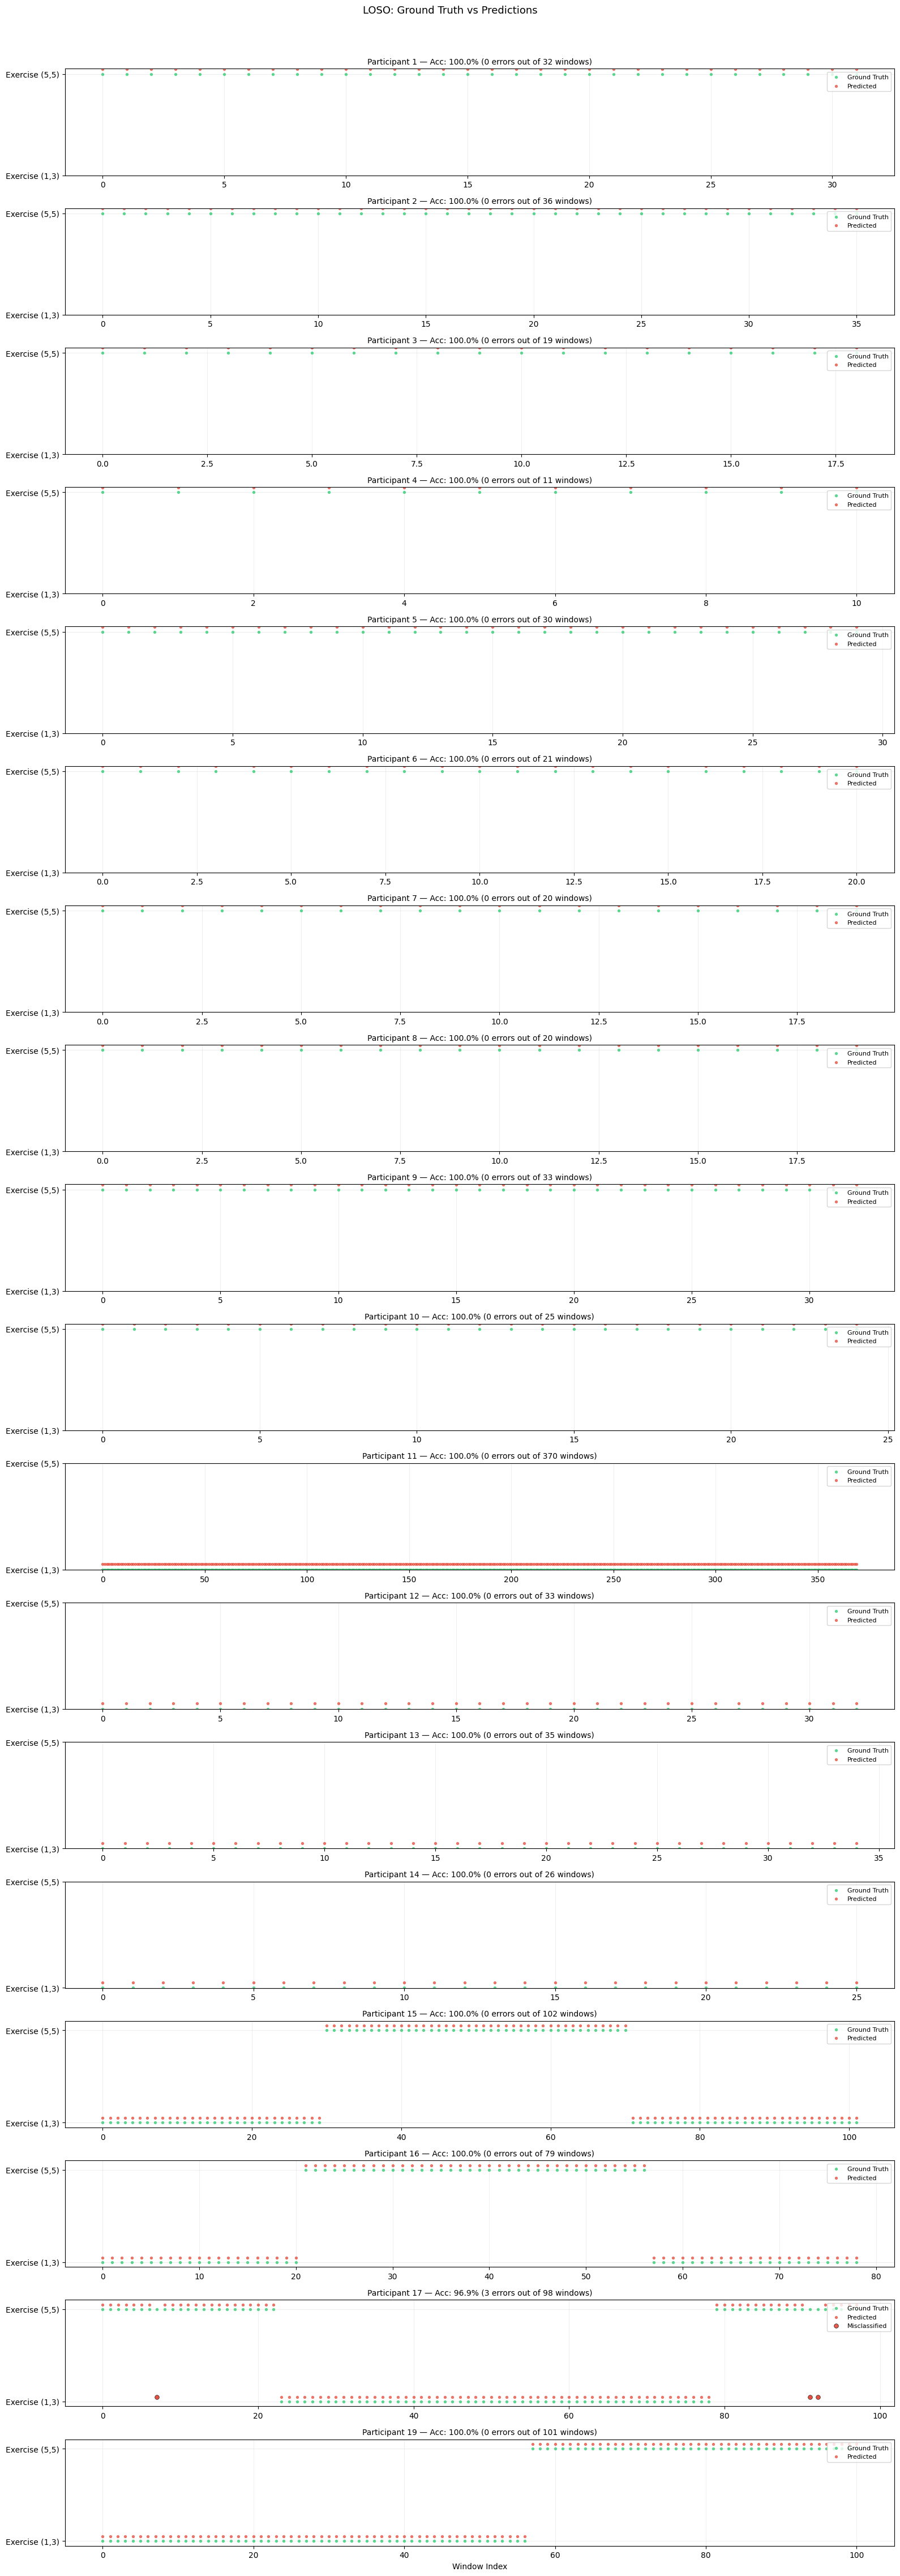

In [ ]:
n_folds = len(fold_data)
fig, axes = plt.subplots(n_folds, 1, figsize=(16, 2.5 * n_folds), sharex=False)
if n_folds == 1:
    axes = [axes]

for ax, fd in zip(axes, fold_data):
    windows = np.arange(len(fd["y_true"]))

    # Plot ground truth and predictions slightly offset so both are visible
    ax.scatter(windows, fd["y_true"], c="#2ecc71", s=8, alpha=0.7, label="Ground Truth", zorder=2)
    ax.scatter(windows, fd["y_pred"] + 0.05, c="#e74c3c", s=8, alpha=0.7, label="Predicted", zorder=2)

    # Highlight mismatches
    mismatches = fd["y_true"] != fd["y_pred"]
    if mismatches.any():
        ax.scatter(windows[mismatches], fd["y_pred"][mismatches] + 0.05,
                   c="#e74c3c", s=30, edgecolors="black", linewidths=0.5,
                   alpha=0.9, zorder=3, label="Misclassified")

    acc = accuracy_score(fd["y_true"], fd["y_pred"])
    n_wrong = mismatches.sum()
    ax.set_title(f"Participant {fd['participant']} — Acc: {acc*100:.1f}% "
                 f"({n_wrong} errors out of {len(fd['y_true'])} windows)", fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Exercise (1,3)", "Exercise (5,5)"])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Window Index")
fig.suptitle("LOSO: Ground Truth vs Predictions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

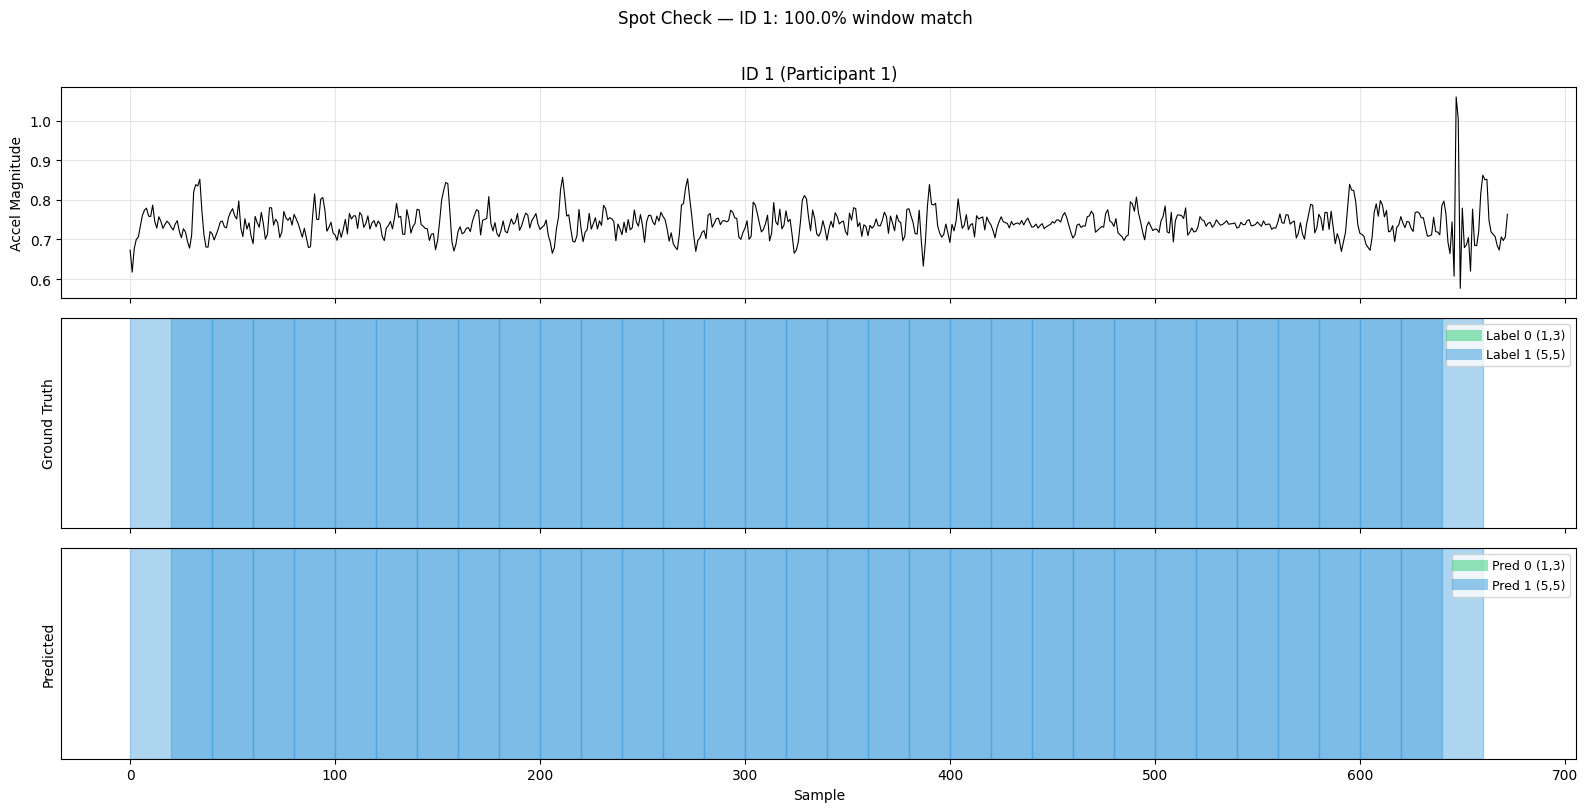

In [ ]:
# Pick a random ID from the dev set to spot-check
spot_participant = fold_data[0]["participant"]
spot_ids = df_processed[df_processed["participant"] == spot_participant]["ID"].unique()
spot_id = spot_ids[0]

spot_df = df_processed[df_processed["ID"] == spot_id].reset_index(drop=True)
spot_imu = spot_df[IMU_COLS].values
spot_labels = spot_df["label"].values

# Get model predictions for this ID's windows
spot_windows, spot_wlabels = pp.segment_single(spot_imu, spot_labels)
spot_X = np.array(spot_windows, dtype=np.float32)
spot_y = np.array(spot_wlabels, dtype=np.int64)

model.eval()
with torch.no_grad():
    spot_preds = model(torch.FloatTensor(spot_X).to(DEVICE)).argmax(1).cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

# Plot raw accelerometer magnitude
accel_mag = np.sqrt(spot_imu[:, 0]**2 + spot_imu[:, 1]**2 + spot_imu[:, 2]**2)
axes[0].plot(accel_mag, color="black", linewidth=0.8)
axes[0].set_ylabel("Accel Magnitude")
axes[0].set_title(f"ID {spot_id} (Participant {spot_participant})")
axes[0].grid(True, alpha=0.3)

# Plot ground truth as colored regions
colors_map = {0: "#2ecc71", 1: "#3498db"}
label_names_short = {0: "(1,3)", 1: "(5,5)"}

for i, lbl in enumerate(spot_y):
    start = i * pp.step_size
    end = start + pp.window_size
    axes[1].axvspan(start, end, alpha=0.4, color=colors_map[lbl])
axes[1].set_ylabel("Ground Truth")
axes[1].set_yticks([])
# Manual legend
for lbl, color in colors_map.items():
    axes[1].plot([], [], color=color, linewidth=8, alpha=0.5,
                 label=f"Label {lbl} {label_names_short[lbl]}")
axes[1].legend(loc="upper right", fontsize=9)

# Plot predictions as colored regions
for i, pred in enumerate(spot_preds):
    start = i * pp.step_size
    end = start + pp.window_size
    axes[2].axvspan(start, end, alpha=0.4, color=colors_map[pred])
axes[2].set_ylabel("Predicted")
axes[2].set_xlabel("Sample")
axes[2].set_yticks([])
for lbl, color in colors_map.items():
    axes[2].plot([], [], color=color, linewidth=8, alpha=0.5,
                 label=f"Pred {lbl} {label_names_short[lbl]}")
axes[2].legend(loc="upper right", fontsize=9)

match_pct = (spot_y == spot_preds).mean() * 100
fig.suptitle(f"Spot Check — ID {spot_id}: {match_pct:.1f}% window match", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 13. Variant Inference: Baseline (Before Fine-Tuning)

The model was trained on core exercises **(1,3) Arm Curls** and **(5,5) Bench Press**
from `golden_dataset_v0.csv`.

Now we load **`OurData_v5_scaled.csv`**, extract all exercise variants (every pair
except 1,3 and 5,5), and test whether the trained model correctly classifies them
by their parent class — i.e., does an Incline Bench Press (5,6) still get classified
as Bench Press?

In [ ]:
# ============================================================
# Load OurData for variants, discover pairs, preprocess
# ============================================================

OUR_DATA_PATH = os.path.join(BASE_PATH, "data/OurData_v5_scaled.csv")
df_our = pd.read_csv(OUR_DATA_PATH)
print(f"OurData: {df_our.shape[0]:,} rows, {df_our.shape[1]} columns")
print(f"Participants: {sorted(df_our['participant'].unique())}")

# Show all (parent, child) pairs in this dataset
all_pairs_our = df_our.groupby(["parent", "child"]).size().reset_index(name="rows")
print(f"\nAll (parent, child) pairs in OurData:")
print(all_pairs_our.to_string(index=False))

# Identify variant pairs (everything except the training pairs)
training_pairs = set(map(tuple, KEEP_PAIRS))
variant_pairs = [(int(row["parent"]), int(row["child"]))
                 for _, row in all_pairs_our.iterrows()
                 if (row["parent"], row["child"]) not in training_pairs]

print(f"\nTraining pairs (used for model training): {sorted(training_pairs)}")
print(f"Variant pairs (unseen by model):          {sorted(variant_pairs)}")

# Filter to variant data only
variant_mask = pd.Series(False, index=df_our.index)
for p, c in variant_pairs:
    variant_mask |= (df_our["parent"] == p) & (df_our["child"] == c)
df_variants = df_our[variant_mask].copy().reset_index(drop=True)

# Assign labels based on parent class (same mapping as training)
df_variants["label"] = df_variants["parent"].map(LABEL_MAP)

print(f"\nVariant data: {len(df_variants):,} rows, {df_variants['ID'].nunique()} IDs")
print(f"  Arm Curl variants (parent=1):    {(df_variants['parent'] == 1).sum():,} rows")
print(f"  Bench Press variants (parent=5): {(df_variants['parent'] == 5).sum():,} rows")

# Preprocess: denoise + normalize using TRAINING fit (not re-fit)
print("\nPreprocessing variant data...")
imu_denoised = pp.denoise(df_variants[IMU_COLS].values)
df_var_proc = df_variants.copy()
df_var_proc[IMU_COLS] = imu_denoised
df_var_proc[IMU_COLS] = pp.transform_normalize(df_var_proc[IMU_COLS].values)

# Segment per ID — also track which (parent, child) pair each window belongs to
# so we can report per-pair accuracy later
all_X, all_y, all_parts, all_pair_labels, all_ids = [], [], [], [], []

for uid in df_var_proc["ID"].unique():
    subset = df_var_proc[df_var_proc["ID"] == uid]
    if len(subset) < pp.window_size:
        print(f"  ID {uid}: {len(subset)} rows — too short, skipping")
        continue

    imu = subset[IMU_COLS].values
    labels = subset["label"].values
    pair = (int(subset["parent"].iloc[0]), int(subset["child"].iloc[0]))
    participant = int(subset["participant"].iloc[0])

    windows, window_labels = pp.segment_single(imu, labels)
    all_X.extend(windows)
    all_y.extend(window_labels)
    all_parts.extend([participant] * len(windows))
    all_pair_labels.extend([pair] * len(windows))
    all_ids.extend([int(uid)] * len(windows))

X_var_all = np.array(all_X, dtype=np.float32)
y_var_all = np.array(all_y, dtype=np.int64)
parts_var_all = np.array(all_parts)
pairs_var_all = np.array(all_pair_labels)
ids_var_all = np.array(all_ids)

print(f"\nSegmented: {X_var_all.shape[0]} windows total")
print(f"  Label 0 (Arm Curl variants):    {(y_var_all == 0).sum()}")
print(f"  Label 1 (Bench Press variants):  {(y_var_all == 1).sum()}")

OurData: 52,828 rows, 11 columns
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

All (parent, child) pairs in OurData:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542

Training pairs (used for model training): [(1, 3), (5, 5)]
Variant pairs (unseen by model):          [(1, 1), (1, 2), (1, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10)]

Variant data: 42,937 rows, 78 IDs
  Arm Curl variants (parent=1):    16,565 rows
  Bench Press variants (parent=5): 26,372 rows

Preprocessing variant data...

Segmented: 2028 windows total
  Label 0 (Arm Curl variants):    785
  Label 1 (Bench Press variants):  1243


In [ ]:
# ============================================================
# Baseline inference on ALL variant data (before any fine-tuning)
# ============================================================

loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(torch.FloatTensor(X_var_all).to(DEVICE))
    baseline_preds = logits.argmax(1).cpu().numpy()
    baseline_probs = torch.softmax(logits, dim=1).cpu().numpy()

# Per-pair results
baseline_results = []
unique_pairs = sorted(set(map(tuple, pairs_var_all.tolist())))

for pair in unique_pairs:
    p, c = pair
    mask = (pairs_var_all[:, 0] == p) & (pairs_var_all[:, 1] == c)
    preds_pair = baseline_preds[mask]
    expected = LABEL_MAP[p]

    acc = (preds_pair == expected).mean()
    mean_conf = baseline_probs[mask, expected].mean()

    baseline_results.append({
        "parent": p, "child": c,
        "expected": "Arm Curl" if expected == 0 else "Bench Press",
        "n_windows": int(mask.sum()),
        "accuracy": acc,
        "mean_confidence": mean_conf,
        "pred_arm_curl": int((preds_pair == 0).sum()),
        "pred_bench_press": int((preds_pair == 1).sum()),
    })

print("Baseline inference complete.")

Baseline inference complete.


In [ ]:
# ============================================================
# Baseline summary table
# ============================================================

var_df = pd.DataFrame(baseline_results)
var_df["pair"] = var_df.apply(lambda r: f"({int(r['parent'])},{int(r['child'])})", axis=1)
var_df = var_df[["pair", "expected", "n_windows",
                 "pred_arm_curl", "pred_bench_press", "accuracy", "mean_confidence"]]
var_df.columns = ["(Parent,Child)", "Expected Class", "Windows",
                  "Pred Arm Curl", "Pred Bench Press", "Accuracy", "Mean Conf"]

print("Baseline Variant Inference Results (BEFORE fine-tuning)")
print("=" * 85)
print("Model trained on: (1,3) Arm Curls  +  (5,5) Bench Press")
print("Testing on: unseen exercise variations from OurData_v5_scaled.csv\n")
display(var_df.round(4))

# Aggregated by expected class
print("\n--- Aggregated by expected class ---")
for expected in ["Arm Curl", "Bench Press"]:
    subset = var_df[var_df["Expected Class"] == expected]
    if len(subset) == 0:
        continue
    total_windows = subset["Windows"].sum()
    correct = subset["Pred Arm Curl"].sum() if expected == "Arm Curl" else subset["Pred Bench Press"].sum()
    overall_acc = correct / total_windows if total_windows > 0 else 0
    print(f"  {expected} variants: {overall_acc*100:.2f}% correct "
          f"({int(correct)}/{int(total_windows)} windows across {len(subset)} variant pairs)")

Baseline Variant Inference Results (BEFORE fine-tuning)
Model trained on: (1,3) Arm Curls  +  (5,5) Bench Press
Testing on: unseen exercise variations from OurData_v5_scaled.csv



,"(Parent,Child)",Expected Class,Windows,Pred Arm Curl,Pred Bench Press,Accuracy,Mean Conf
0,"(1,1)",Arm Curl,251,243,8,0.9681,0.9694
1,"(1,2)",Arm Curl,264,264,0,1.0000,0.9985
2,"(1,4)",Arm Curl,270,98,172,0.3630,0.3773
3,"(5,6)",Bench Press,247,6,241,0.9757,0.9742
4,"(5,7)",Bench Press,210,18,192,0.9143,0.9075
5,"(5,8)",Bench Press,266,19,247,0.9286,0.9119
6,"(5,9)",Bench Press,257,49,208,0.8093,0.8087
7,"(5,10)",Bench Press,263,20,243,0.9240,0.9081



--- Aggregated by expected class ---
  Arm Curl variants: 77.07% correct (605/785 windows across 3 variant pairs)
  Bench Press variants: 90.99% correct (1131/1243 windows across 5 variant pairs)


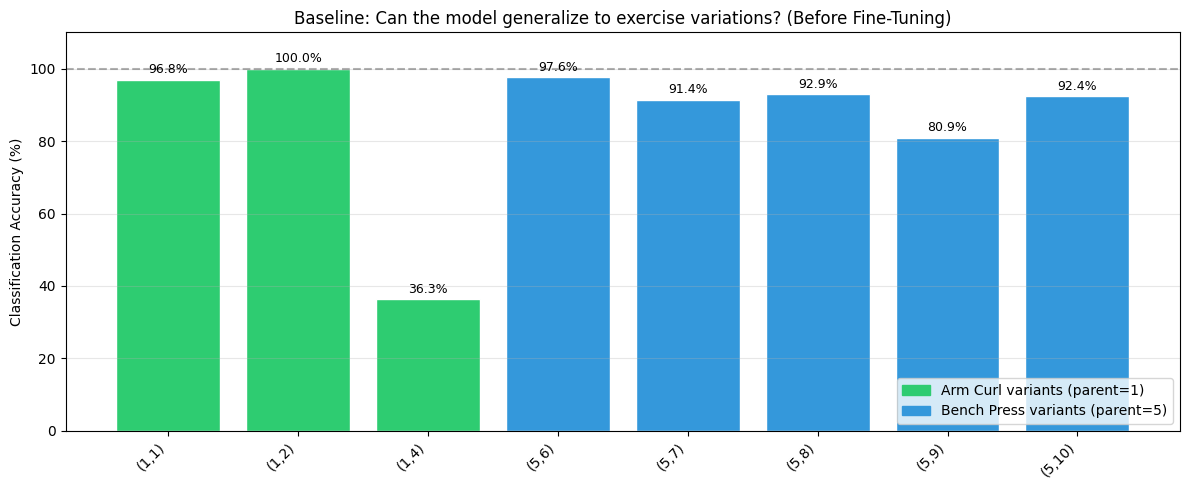

In [ ]:
# ============================================================
# Baseline bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

colors = ["#2ecc71" if row["Expected Class"] == "Arm Curl" else "#3498db"
          for _, row in var_df.iterrows()]
bars = ax.bar(range(len(var_df)), var_df["Accuracy"] * 100, color=colors, edgecolor="white")

ax.set_xticks(range(len(var_df)))
ax.set_xticklabels(var_df["(Parent,Child)"], rotation=45, ha="right")
ax.set_ylabel("Classification Accuracy (%)")
ax.set_title("Baseline: Can the model generalize to exercise variations? (Before Fine-Tuning)")
ax.set_ylim(0, 110)
ax.axhline(y=100, color="black", linestyle="--", alpha=0.3)

for bar, acc in zip(bars, var_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label="Arm Curl variants (parent=1)"),
    Patch(color="#3498db", label="Bench Press variants (parent=5)"),
], loc="lower right")

ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 14. Progressive Fine-Tuning on Exercise Variants

### The Situation

Our model was trained on just two exercises: (1,3) Arm Curl and (5,5) Bench Press. But in the real world, people don't do exactly those two movements — they do variations. Someone might do an Incline Bench Press (5,6), a Hammer Curl (1,2), or a Close-Grip Bench Press (5,7). These are all still "bench presses" or "arm curls" at the parent-class level, but the specific movement patterns look different in the IMU data.

In Section 13, we tested the trained model on all these variants without any additional training and measured how well it generalizes. For variants that happen to look similar to the core exercises, the model will classify them correctly just from what it already learned. For variants that look different enough, it may struggle.

### The Question We're Answering

If the model doesn't generalize well to some variants, **how much variant data would we need to show it before it starts classifying them correctly?** This is practically important: collecting IMU data is expensive and time-consuming, and knowing whether we need 5%, 20%, or 100% of a full variant dataset tells us how much effort to budget for future data collection.


### Why a Lower Learning Rate

When we originally trained the model, we used a learning rate found by our hyperparameter sweep — the rate that worked best for learning from scratch. For fine-tuning, we deliberately use a learning rate **ten times smaller**. The model already knows the fundamental difference between arm curls and bench presses; we don't want to overwrite that knowledge. A smaller learning rate means each gradient update nudges the weights only slightly, gently expanding what the model knows rather than rebuilding it. If we used the original learning rate, large weight updates could destroy the original learned features — a phenomenon called **catastrophic forgetting**, where fine-tuning on new data causes a model to forget what it previously knew.

### The Progressive Setup

We want a curve, not a single number. So we repeat the fine-tuning process at several data percentages: 5%, 10%, 15%, 20%, 25%, 30%, 40%, 50%, 75%, and 100%. Each point on this curve tells us "if you gave the model this much variant data, here's the accuracy it would reach." We can then look at the curve and see where it plateaus — that's the sweet spot between data collection effort and accuracy gain. If it plateaus at 25%, we know we don't need to collect any more; if it's still climbing at 100%, we know more data would help.

### Why Each Percentage Step Is Independent

At the start of each step, we reload the original trained weights from disk — meaning the 10% run does not benefit from any training that happened during the 5% run. This is critical for making the percentage values meaningful. If we instead kept accumulating training across steps (cumulative fine-tuning), the 10% run would have effectively seen 5% + 10% = 15% of the data, and its accuracy wouldn't really be telling us what 10% of data achieves. Independent runs give us clean, directly-comparable data points on our curve.

### What "Stratified ID Sampling" Means

There are two important details in how we sample. First, we sample **whole IDs, not individual windows**. Each ID in our data represents a single complete exercise set — roughly 10 reps performed back-to-back. If we randomly pulled individual windows, we'd get disconnected fragments: window 3 from one set, window 17 from another, window 8 from a third. The model would see choppy snippets instead of coherent movement patterns. By sampling at the ID level, every sampled unit is a complete, uninterrupted set of an exercise.

Second, we sample in a **stratified** way at the (parent, child) pair level. Our variant data contains multiple specific exercises — (1,1), (1,2), (1,4) for arm curl variants and (5,6) through (5,10) for bench press variants. If we just randomly grabbed IDs, a small sample might happen to pull only Incline Bench Press and Decline Bench Press while missing variants of arm curls entirely. The model would then only learn about the variants it saw, and results would be misleading. Stratified sampling by pair means that for every unique (parent, child) combination, we separately sample the same percentage of its IDs and then combine them. At 25%, we pull 25% of (1,1) IDs AND 25% of (1,2) IDs AND 25% of (1,4) IDs AND so on — guaranteeing that every variant is proportionally represented at every step, no matter how small the percentage.

### The Split: Who We Fine-Tune On vs Evaluate On

Our variant data comes from five participants (15, 16, 17, 18, 19). Participant 15 is our held-out test participant — they've never appeared in any training or validation up to this point, and we want to keep that status. So we use variants from **participants 16, 17, 18, and 19 for fine-tuning**, and variants from **participant 15 for evaluation only**. This way, when we report that "after fine-tuning on 25% of variant data, the model reaches X% accuracy on variants," that X% reflects genuine generalization to an unseen person — not inflated numbers from testing on data the model already saw during fine-tuning.

### Watching for Catastrophic Forgetting

At every percentage step, in addition to measuring how well the fine-tuned model performs on variants, we also re-evaluate it on the original core test set from Section 10. If fine-tuning is going well, core accuracy should stay roughly the same as before. If core accuracy starts dropping, it means fine-tuning is eroding the model's original knowledge of the core exercises — catastrophic forgetting in action. The two accuracy curves plotted side by side (variant accuracy hopefully going up, core accuracy hopefully staying flat) tell the full story of whether fine-tuning is a net win, or whether we're robbing Peter to pay Paul.

In [ ]:
# ============================================================
# Split variant data: fine-tune vs eval (by participant)
# ============================================================

ft_mask = ~np.isin(parts_var_all, VARIANT_EVAL_PARTICIPANTS)
eval_mask = np.isin(parts_var_all, VARIANT_EVAL_PARTICIPANTS)

X_var_ft     = X_var_all[ft_mask]
y_var_ft     = y_var_all[ft_mask]
pairs_var_ft = pairs_var_all[ft_mask]
ids_var_ft   = ids_var_all[ft_mask]

X_var_eval     = X_var_all[eval_mask]
y_var_eval     = y_var_all[eval_mask]
pairs_var_eval = pairs_var_all[eval_mask]
ids_var_eval   = ids_var_all[eval_mask]

print("Variant data split:")
print(f"  Fine-tune set: {len(X_var_ft)} windows "
      f"(participants {sorted(set(parts_var_all[ft_mask].tolist()))})")
print(f"    Label 0 (Arm Curl):    {(y_var_ft == 0).sum()}")
print(f"    Label 1 (Bench Press): {(y_var_ft == 1).sum()}")
print(f"\n  Eval set: {len(X_var_eval)} windows "
      f"(participant {sorted(set(parts_var_all[eval_mask].tolist()))})")
print(f"    Label 0 (Arm Curl):    {(y_var_eval == 0).sum()}")
print(f"    Label 1 (Bench Press): {(y_var_eval == 1).sum()}")

# Show eval set pair breakdown so we know what we're measuring
print(f"\n  Eval set per-pair breakdown:")
eval_pairs = sorted(set(map(tuple, pairs_var_eval.tolist())))
for p, c in eval_pairs:
    mask = (pairs_var_eval[:, 0] == p) & (pairs_var_eval[:, 1] == c)
    expected = "Arm Curl" if LABEL_MAP[p] == 0 else "Bench Press"
    print(f"    ({p},{c}) {expected}: {mask.sum()} windows")


# ---- Helper function: evaluate a model on variant data ----
def evaluate_variants(model, X, y, pairs, device):
    """
    Run inference, return overall metrics and per-pair accuracy breakdown.
    """
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X).to(device))
        preds = logits.argmax(1).cpu().numpy()

    overall_acc = accuracy_score(y, preds)
    overall_f1  = f1_score(y, preds, average="macro", zero_division=0)

    per_pair = {}
    for pair in sorted(set(map(tuple, pairs.tolist()))):
        p, c = pair
        mask = (pairs[:, 0] == p) & (pairs[:, 1] == c)
        if mask.sum() == 0:
            continue
        expected = LABEL_MAP[p]
        pair_preds = preds[mask]
        per_pair[(p, c)] = {
            "accuracy": (pair_preds == expected).mean(),
            "n_windows": int(mask.sum()),
            "expected": "Arm Curl" if expected == 0 else "Bench Press",
        }

    return {"overall_acc": overall_acc, "overall_f1": overall_f1,
            "preds": preds, "per_pair": per_pair}

Variant data split:
  Fine-tune set: 1500 windows (participants [16, 17, 18, 19])
    Label 0 (Arm Curl):    612
    Label 1 (Bench Press): 888

  Eval set: 528 windows (participant [15])
    Label 0 (Arm Curl):    173
    Label 1 (Bench Press): 355

  Eval set per-pair breakdown:
    (1,1) Arm Curl: 61 windows
    (1,2) Arm Curl: 55 windows
    (1,4) Arm Curl: 57 windows
    (5,6) Bench Press: 62 windows
    (5,7) Bench Press: 34 windows
    (5,8) Bench Press: 100 windows
    (5,9) Bench Press: 70 windows
    (5,10) Bench Press: 89 windows


### A Note on Sampling: Why We Switched from Percentages to ID Counts

Our initial approach to the progressive fine-tuning curve was to iterate through fixed percentages of the variant data — 5%, 10%, 15%, and so on up to 100%. This seemed like the natural way to ask "how much data does the model need?" because it gave us nice round numbers to plot and report.

After running the first version, however, we noticed a large jump in variant accuracy between the 50% and 75% steps — the curve climbed from roughly 76% to 94% in a single increment, with no intermediate data points to show what was happening in between. The natural instinct was to add finer percentage steps (55%, 60%, 65%, 70%) to characterize that transition more precisely.

That's when we hit a limitation of the percentage-based approach. Each variant pair in our fine-tune set only contains a small number of IDs — most pairs have 8 IDs, some have fewer. When we apply a percentage to such a small pool, many different percentage values round to the same integer number of IDs. For example, with 8 IDs in a pair:

- 50% → round(4.0) = 4 IDs
- 55% → round(4.4) = 4 IDs (same as 50%)
- 60% → round(4.8) = 5 IDs
- 65% → round(5.2) = 5 IDs (same as 60%)

So adding a step at "55%" wouldn't actually show us anything new — it would re-run the exact same sample size as 50%, and the only difference would be random sampling variance. Between 50% and 75%, there are really only two meaningful transitions: 4 IDs → 5 IDs, and 5 IDs → 6 IDs. The percentage axis was hiding this discreteness and creating the illusion of a continuous sweep.

The cleaner approach — the one we've now adopted — is to iterate directly over the quantity the model actually sees: **the number of IDs per variant pair**. We start at 1 ID per pair, then 2, then 3, all the way up to the maximum available. Each step corresponds to a genuinely different sample size, and every data point on the curve represents a real change in the training data. At the end, we still report the equivalent percentage as a secondary reference so the results remain interpretable in those terms, but the primary x-axis of our plot is the ID count.

This reframing also makes the stopping condition self-evident: we stop when we've used every available ID, rather than picking an arbitrary percentage ceiling. And because every step now corresponds to a meaningfully different amount of data, the resulting curve is a true characterization of how model performance scales with variant data — not a series of redundant measurements hiding behind different-looking percentage labels.

In [ ]:
# ============================================================
# Progressive fine-tuning loop (iterating by IDs per pair)
# ============================================================

FINE_TUNE_LR     = best_lr / 10    # gentle updates to preserve learned features
FINE_TUNE_EPOCHS = 20              # fixed epoch count per step

# Determine how many IDs each variant pair has in the fine-tune set
pair_id_counts = {}
for pair in sorted(set(map(tuple, pairs_var_ft.tolist()))):
    p, c = pair
    pair_mask = (pairs_var_ft[:, 0] == p) & (pairs_var_ft[:, 1] == c)
    pair_id_counts[pair] = len(np.unique(ids_var_ft[pair_mask]))

max_ids_per_pair = max(pair_id_counts.values())
total_fine_tune_ids = sum(pair_id_counts.values())

print(f"Fine-tune set IDs per pair:")
for pair, n in sorted(pair_id_counts.items()):
    print(f"  ({pair[0]},{pair[1]}): {n} IDs")
print(f"Max IDs per pair: {max_ids_per_pair}")
print(f"Total fine-tune IDs: {total_fine_tune_ids}\n")

np.random.seed(42)
ft_curve = []

# Track the best-performing fine-tuned model across all steps
best_ft_acc = -1
best_ft_state = None
best_ft_n_ids = None

# Baseline eval (before any fine-tuning)
baseline_eval = evaluate_variants(loaded_model, X_var_eval, y_var_eval,
                                  pairs_var_eval, DEVICE)
print(f"Baseline variant eval accuracy (no fine-tuning): "
      f"{baseline_eval['overall_acc']*100:.2f}%\n")

# Iterate: 1 ID per pair, 2 IDs per pair, ..., up to max
for n_ids_per_pair in range(1, max_ids_per_pair + 1):
    print(f"\n{'='*60}")
    print(f"  Fine-tuning with {n_ids_per_pair} ID(s) per pair "
          f"(lr={FINE_TUNE_LR:.1e}, epochs={FINE_TUNE_EPOCHS})")
    print(f"{'='*60}")

    # ---- Stratified ID sampling: take n_ids_per_pair from each (parent, child) ----
    # If a pair has fewer than n_ids_per_pair IDs available, take all of them
    sampled_ids = []
    for pair in sorted(pair_id_counts.keys()):
        p, c = pair
        pair_mask = (pairs_var_ft[:, 0] == p) & (pairs_var_ft[:, 1] == c)
        pair_ids = np.unique(ids_var_ft[pair_mask])
        n_to_sample = min(n_ids_per_pair, len(pair_ids))
        sampled = np.random.choice(pair_ids, n_to_sample, replace=False)
        sampled_ids.extend(sampled.tolist())

    # Compute the actual percentage of the fine-tune set this represents
    pct_actual = len(sampled_ids) / total_fine_tune_ids * 100

    # Pull all windows belonging to sampled IDs
    sample_mask = np.isin(ids_var_ft, sampled_ids)
    X_sub = X_var_ft[sample_mask]
    y_sub = y_var_ft[sample_mask]

    print(f"  Sampled {len(sampled_ids)} IDs ({pct_actual:.1f}% of fine-tune set) "
          f"→ {len(X_sub)} windows "
          f"(label 0: {(y_sub == 0).sum()}, label 1: {(y_sub == 1).sum()})")

    # ---- Reload original trained weights (independent from previous steps) ----
    model = CNN_LSTM(
        in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES
    ).to(DEVICE)
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))

    # ---- Fine-tune ----
    optimizer = torch.optim.Adam(model.parameters(), lr=FINE_TUNE_LR)
    loss_fn = nn.CrossEntropyLoss()

    X_sub_t = torch.FloatTensor(X_sub).to(DEVICE)
    y_sub_t = torch.LongTensor(y_sub).to(DEVICE)
    train_dl = DataLoader(TensorDataset(X_sub_t, y_sub_t),
                          batch_size=min(32, len(X_sub)), shuffle=True)

    model.train()
    for epoch in range(FINE_TUNE_EPOCHS):
        total_loss, n = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n += 1
        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:3d}  loss={total_loss/n:.4f}")

    # ---- Evaluate on variant eval set (held-out participant) ----
    var_eval = evaluate_variants(model, X_var_eval, y_var_eval,
                                 pairs_var_eval, DEVICE)

    # ---- Evaluate on core test set (check for catastrophic forgetting) ----
    model.eval()
    with torch.no_grad():
        core_preds = model(
            torch.FloatTensor(X_test).to(DEVICE)
        ).argmax(1).cpu().numpy()
    core_acc = accuracy_score(y_test, core_preds)
    core_f1  = f1_score(y_test, core_preds, average="macro", zero_division=0)

    ft_curve.append({
        "n_ids_per_pair": n_ids_per_pair,
        "n_ids_total": len(sampled_ids),
        "pct": pct_actual,
        "n_windows": len(X_sub),
        "variant_acc": var_eval["overall_acc"],
        "variant_f1":  var_eval["overall_f1"],
        "core_acc": core_acc,
        "core_f1":  core_f1,
        "per_pair": var_eval["per_pair"],
    })

    # ---- Save this model's weights if it's the best so far ----
    if var_eval["overall_acc"] > best_ft_acc:
        best_ft_acc = var_eval["overall_acc"]
        best_ft_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_ft_n_ids = n_ids_per_pair
        print(f"  ★ New best variant accuracy — saving state")

    print(f"\n  Variant eval acc:  {var_eval['overall_acc']*100:.2f}%  "
          f"F1: {var_eval['overall_f1']*100:.2f}%")
    print(f"  Core test acc:     {core_acc*100:.2f}%  "
          f"F1: {core_f1*100:.2f}%  ← watch for degradation")

print("\n\n✓ Progressive fine-tuning complete!")

# ---- Save the best fine-tuned model to disk ----
ft_save_path = os.path.join(BASE_PATH, "cnn_lstm_imu_finetuned.pt")
torch.save(best_ft_state, ft_save_path)
print(f"\nBest fine-tuned model saved:")
print(f"  IDs per pair: {best_ft_n_ids}")
print(f"  Variant eval accuracy: {best_ft_acc*100:.2f}%")
print(f"  Path: {ft_save_path}")

Fine-tune set IDs per pair:
  (1,1): 6 IDs
  (1,2): 8 IDs
  (1,4): 8 IDs
  (5,6): 8 IDs
  (5,7): 8 IDs
  (5,8): 8 IDs
  (5,9): 8 IDs
  (5,10): 8 IDs
Max IDs per pair: 8
Total fine-tune IDs: 62

Baseline variant eval accuracy (no fine-tuning): 85.04%


  Fine-tuning with 1 ID(s) per pair (lr=1.0e-04, epochs=20)
  Sampled 8 IDs (12.9% of fine-tune set) → 190 windows (label 0: 87, label 1: 103)
    Epoch   5  loss=0.1535
    Epoch  10  loss=0.0708
    Epoch  15  loss=0.0734
    Epoch  20  loss=0.0067
  ★ New best variant accuracy — saving state

  Variant eval acc:  59.28%  F1: 57.73%
  Core test acc:     98.82%  F1: 98.82%  ← watch for degradation

  Fine-tuning with 2 ID(s) per pair (lr=1.0e-04, epochs=20)
  Sampled 16 IDs (25.8% of fine-tune set) → 374 windows (label 0: 157, label 1: 217)
    Epoch   5  loss=0.1918
    Epoch  10  loss=0.1499
    Epoch  15  loss=0.0521
    Epoch  20  loss=0.0449
  ★ New best variant accuracy — saving state

  Variant eval acc:  74.43%  F1: 71.28%
  Core

In [ ]:
# ============================================================
# Fine-tuning results table
# ============================================================

curve_df = pd.DataFrame([{
    "IDs per Pair":     r["n_ids_per_pair"],
    "Total IDs Used":   r["n_ids_total"],
    "% of FT Set":      r["pct"],
    "Windows Used":     r["n_windows"],
    "Variant Acc (%)":  r["variant_acc"] * 100,
    "Variant F1 (%)":   r["variant_f1"] * 100,
    "Core Acc (%)":     r["core_acc"] * 100,
    "Core F1 (%)":      r["core_f1"] * 100,
} for r in ft_curve])

print("Progressive Fine-Tuning Results")
print("=" * 85)
print(f"Fine-tune LR: {FINE_TUNE_LR:.1e}  |  Epochs: {FINE_TUNE_EPOCHS}  |  "
        f"Eval participant: {sorted(set(parts_var_all[eval_mask].tolist()))}")
print(f"Baseline variant accuracy (before fine-tuning): "
      f"{baseline_eval['overall_acc']*100:.2f}%\n")
display(curve_df.round(2))

Progressive Fine-Tuning Results
Fine-tune LR: 1.0e-04  |  Epochs: 20  |  Eval participant: [15]
Baseline variant accuracy (before fine-tuning): 85.04%



,IDs per Pair,Total IDs Used,% of FT Set,Windows Used,Variant Acc (%),Variant F1 (%),Core Acc (%),Core F1 (%)
0,1,8,12.90,190,59.28,57.73,98.82,98.82
1,2,16,25.81,374,74.43,71.28,100.00,100.00
2,3,24,38.71,589,85.23,81.98,100.00,100.00
3,4,32,51.61,731,79.92,76.87,100.00,100.00
4,5,40,64.52,993,84.28,79.78,100.00,100.00
5,6,48,77.42,1178,90.72,88.88,100.00,100.00
6,7,55,88.71,1317,86.93,84.28,100.00,100.00
7,8,62,100.00,1500,85.61,83.76,100.00,100.00


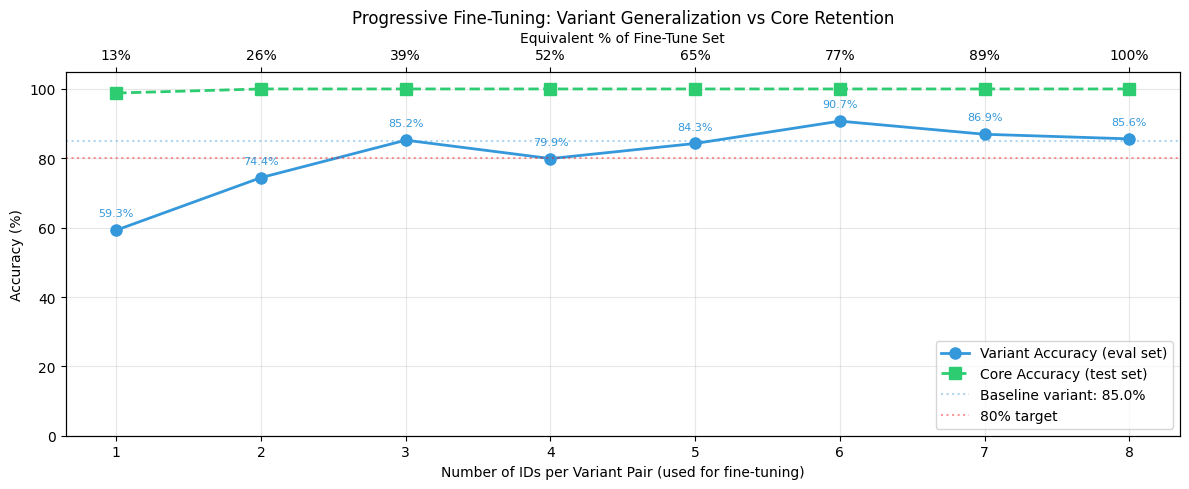

In [ ]:
# ============================================================
# Accuracy curve: variant generalization vs core retention
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

n_ids_vals = [r["n_ids_per_pair"] for r in ft_curve]
pct_vals   = [r["pct"] for r in ft_curve]
var_accs   = [r["variant_acc"] * 100 for r in ft_curve]
core_accs  = [r["core_acc"] * 100 for r in ft_curve]

# Fine-tuning curves
ax.plot(n_ids_vals, var_accs, "o-", color="#3498db", linewidth=2,
        markersize=8, label="Variant Accuracy (eval set)")
ax.plot(n_ids_vals, core_accs, "s--", color="#2ecc71", linewidth=2,
        markersize=8, label="Core Accuracy (test set)")

# Reference lines
ax.axhline(y=baseline_eval["overall_acc"] * 100, color="#3498db",
           linestyle=":", alpha=0.4,
           label=f"Baseline variant: {baseline_eval['overall_acc']*100:.1f}%")
ax.axhline(y=80, color="red", linestyle=":", alpha=0.4, label="80% target")

# Label each point with its variant accuracy
for x, y_val in zip(n_ids_vals, var_accs):
    ax.annotate(f"{y_val:.1f}%", (x, y_val), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="#3498db")

ax.set_xlabel("Number of IDs per Variant Pair (used for fine-tuning)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Progressive Fine-Tuning: Variant Generalization vs Core Retention")
ax.set_xticks(n_ids_vals)

# Secondary x-axis showing the corresponding % of fine-tune set
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(n_ids_vals)
ax2.set_xticklabels([f"{p:.0f}%" for p in pct_vals])
ax2.set_xlabel("Equivalent % of Fine-Tune Set")

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

The green line is the **catastrophic forgetting monitor**. It's the model's accuracy on X_test / y_test, which are the golden dataset core exercise windows held out from the very beginning (the TEST_PARTICIPANTS from cell 14 — core (1,3) and (5,5) windows from golden_dataset participants the model never trained on).


At every fine-tuning step in cell 48, after fine-tuning on some percentage of OurData variants, the model gets re-evaluated on these original golden core windows. The green line is asking: "after nudging the weights to accommodate variants, does the model still know how to classify the core exercises it originally learned?"


The  green line sitting flat at 100% across every percentage step is the result you want. It means fine-tuning on OurData variants isn't degrading the model's original knowledge of (1,3) Arm Curls and (5,5) Bench Press at all — no forgetting is happening. The low fine-tuning learning rate (best_lr / 10) is doing its job of gently expanding knowledge rather than overwriting it.


If that green line had dropped to, say, 70% while the blue line climbed to 90%, that'd be catastrophic forgetting in action — we'd be gaining variant accuracy at the cost of core accuracy, a net wash. But here we're getting pure upside: variant accuracy climbs from ~67% to ~92% while core accuracy stays pinned at 100%.

Another interesting observation:


the baseline (86.7%) is actually higher than several of your fine-tuned points — 5% (67%), 10% (67.4%), 20% (73.5%), and 50% (75.9%) are all below the baseline line. At those percentages, fine-tuning is making things worse on the eval set, not better.


The likely explanation is sample size. With only 4 fine-tune participants and ~1–2 IDs per variant pair at low percentages, the model is seeing so little variant data that it's being pulled slightly in the wrong direction — overfitting to the tiny sample in ways that don't generalize to participant 15. The original pre-trained model was already doing a reasonable job on variants (86.7% isn't bad for zero-shot), and small perturbations with insufficient data end up as net negatives. It's only once you hit 75% and 100% that you meaningfully exceed the baseline.


This is actually a useful finding for your report — it suggests that for your dataset size, partial fine-tuning is counterproductive, and you either need to fine-tune on substantially all of your variant data or not fine-tune at all. The "sweet spot" doesn't exist here the way it would with a larger variant dataset.

Per-Pair Accuracy (%) Across Fine-Tuning Steps
(Baseline = before any fine-tuning)



,Pair,Expected,Baseline,1 ID/pair,2 IDs/pair,3 IDs/pair,4 IDs/pair,5 IDs/pair,6 IDs/pair,7 IDs/pair,8 IDs/pair
0,"(1,1)",Arm Curl,86.9,83.6,86.9,75.4,83.6,67.2,75.4,90.2,90.2
1,"(1,2)",Arm Curl,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,"(1,4)",Arm Curl,3.5,0.0,1.8,21.1,15.8,3.5,54.4,19.3,47.4
3,"(5,6)",Bench Press,100.0,93.5,91.9,100.0,98.4,100.0,96.8,98.4,95.2
4,"(5,7)",Bench Press,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5,"(5,8)",Bench Press,95.0,27.0,63.0,90.0,78.0,95.0,95.0,91.0,79.0
6,"(5,9)",Bench Press,94.3,58.6,84.3,91.4,90.0,100.0,100.0,100.0,94.3
7,"(5,10)",Bench Press,92.1,52.8,79.8,97.8,79.8,96.6,98.9,92.1,86.5


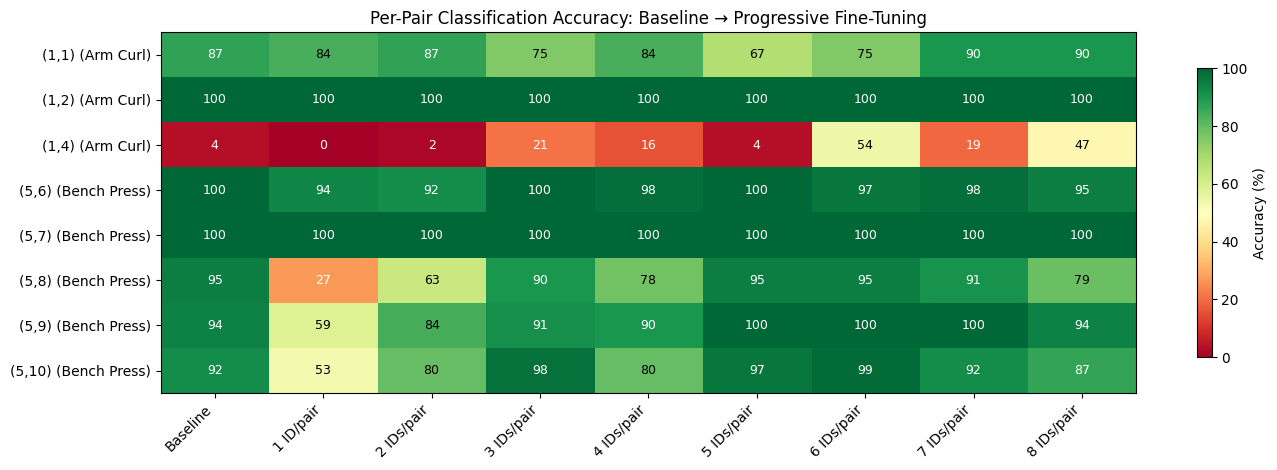

In [ ]:
# ============================================================
# Per-pair accuracy at each fine-tuning step
# ============================================================

pair_list = sorted(ft_curve[0]["per_pair"].keys())

# Build table data
rows = []
for pair in pair_list:
    p, c = pair
    expected = ft_curve[0]["per_pair"][pair]["expected"]
    row = {"Pair": f"({p},{c})", "Expected": expected}

    # Baseline (before fine-tuning)
    bl_pair = baseline_eval["per_pair"].get(pair, {})
    row["Baseline"] = bl_pair.get("accuracy", 0) * 100

    # Each fine-tuning step — keyed by IDs per pair
    for r in ft_curve:
        col_name = f"{r['n_ids_per_pair']} ID{'s' if r['n_ids_per_pair'] != 1 else ''}/pair"
        pair_data = r["per_pair"].get(pair, {})
        row[col_name] = pair_data.get("accuracy", 0) * 100

    rows.append(row)

pair_df = pd.DataFrame(rows)

print("Per-Pair Accuracy (%) Across Fine-Tuning Steps")
print("=" * 90)
print("(Baseline = before any fine-tuning)\n")
display(pair_df.round(1))

# ---- Heatmap visualization ----
step_cols = ["Baseline"] + [
    f"{r['n_ids_per_pair']} ID{'s' if r['n_ids_per_pair'] != 1 else ''}/pair"
    for r in ft_curve
]
heat_data = pair_df[step_cols].values.astype(float)
pair_labels = [f"{row['Pair']} ({row['Expected']})" for _, row in pair_df.iterrows()]

fig, ax = plt.subplots(figsize=(14, max(4, len(pair_list) * 0.6)))
im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(step_cols)))
ax.set_xticklabels(step_cols, rotation=45, ha="right")
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels)

for i in range(len(pair_labels)):
    for j in range(len(step_cols)):
        val = heat_data[i, j]
        color = "white" if val < 40 or val > 85 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=9, color=color)

fig.colorbar(im, ax=ax, shrink=0.8, label="Accuracy (%)")
ax.set_title("Per-Pair Classification Accuracy: Baseline → Progressive Fine-Tuning")
plt.tight_layout()
plt.show()